In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [20]:
cols = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']


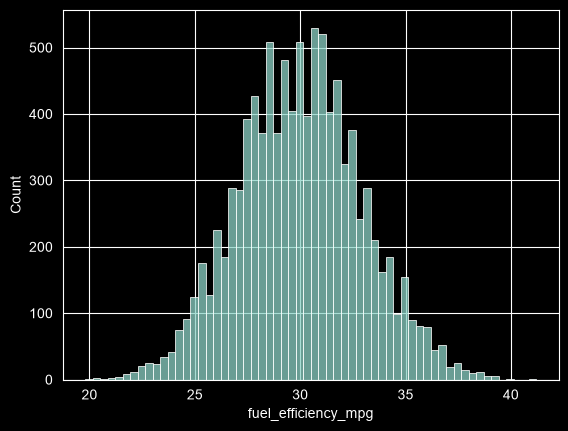

In [21]:
sns.histplot(df['fuel_efficiency_mpg'])

In [24]:
#Q1 missing val
df = df[cols]
df[cols].isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [12]:
#Q2 med of horsepower
df['horsepower'].median()

np.float64(254.0)

In [30]:
# prepare dataset
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[: n_train]]
df_val = df.iloc[idx[n_train: n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val : ]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [31]:
df_train.isnull().sum()

engine_displacement      0
horsepower             539
vehicle_weight           0
model_year               0
dtype: int64

In [32]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,2520,297.0,4510,2013
1,1970,237.0,3990,2012
2,2250,245.0,4230,2008
3,2120,227.0,4420,2021
4,2260,264.0,4090,2003


In [41]:
# Q3

# build linear reg function
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

# calculate rsme
def cal_rmse(y_train, y_pred, dec=3):
    se = (y_train - y_pred) ** 2
    mse = se.mean()
    return round(np.sqrt(mse), dec)


# prep X
def prepare_X(df, fill_zero=True):
    mean = 0
    for col in df.columns:
        if not fill_zero:
            mean = df[col].mean()
        df[col] = df[col].fillna(mean)
    X = df.values
    return X

In [37]:
# fill missing w/ 0
X_train = prepare_X(df_train, fill_zero=True)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, fill_zero=True)
y_pred = w0 + X_val.dot(w)
rmse_score = cal_rmse(y_val, y_pred)

print("RMSE when fill missing w/ 0: ", rmse_score)

# fill missing with mean

X_train = prepare_X(df_train, fill_zero=False)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, fill_zero=False)
y_pred = w0 + X_val.dot(w)
rmse_score = cal_rmse(y_val, y_pred)

print("RMSE when fill missing w/ mean: ", rmse_score)


RMSE when fill missing w/ 0:  2.1633307652783933
RMSE when fill missing w/ mean:  2.1633307652783933


In [39]:
# Q4
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [43]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    rmse_score = cal_rmse(y_val, y_pred, dec=4)

    print("r = ", r, "RMSE = ", rmse_score)



r =  0 RMSE =  2.1634
r =  0.01 RMSE =  2.1633
r =  0.1 RMSE =  2.1777
r =  1 RMSE =  2.2956
r =  5 RMSE =  2.3541
r =  10 RMSE =  2.3639
r =  100 RMSE =  2.3734


In [44]:
# Q5
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_list = []
for seed in seed_list:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']


    X_train = prepare_X(df_train, fill_zero=True)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val, fill_zero=True)
    y_pred = w0 + X_val.dot(w)
    rmse_score = cal_rmse(y_val, y_pred)
    rmse_list.append(rmse_score)

std_rmse = np.std(rmse_list)
print("RMSE Std: ", round(std_rmse, 3))

RMSE Std:  0.029


In [46]:
# Q6
n = len(df)
n_test = int(n * 0.2)
n_train = n - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_test = df.iloc[idx[n_train:]]

y_train = df_train['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']


X_train = prepare_X(df_train, fill_zero=True)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

X_test = prepare_X(df_test, fill_zero=True)
y_pred = w0 + X_test.dot(w)
rmse_score = cal_rmse(y_test, y_pred)

print("RMSE on Test Data: ", rmse_score)

RMSE on Test Data:  2.236
